In [3]:
# Get that data
import pandas as pd
import numpy as np

tournament = pd.read_csv('Tournament Matchups.csv')

tournament.head(8)

,YEAR,BY YEAR NO,TEAM NO,TEAM,SEED,ROUND,CURRENT ROUND,SCORE
0,2025,2140,1141,Auburn,1,4,64,83
1,2025,2139,1145,Alabama St.,16,64,64,63
2,2025,2138,1119,Louisville,8,64,64,75
3,2025,2137,1134,Creighton,9,32,64,89
4,2025,2136,1114,Michigan,5,16,64,68
5,2025,2135,1089,UC San Diego,12,64,64,65
6,2025,2134,1092,Texas A&M,4,32,64,80
7,2025,2133,1080,Yale,13,64,64,71


In [4]:
# Build game-level dataset: every two rows are one game within each YEAR
# Team A = first row, Team B = second row
# Keep years in descending order so recent tournaments appear first
_t = tournament.sort_values(['YEAR', 'BY YEAR NO'], ascending=[False, False]).reset_index(drop=True)

# Create game pairing keys inside each year
_t['_pair_idx'] = _t.groupby('YEAR').cumcount() // 2
_t['_side'] = np.where(_t.groupby('YEAR').cumcount() % 2 == 0, 'A', 'B')

# Split to A/B then merge into one row per game
A = _t[_t['_side'] == 'A'].copy()
B = _t[_t['_side'] == 'B'].copy()

games = A.merge(
    B,
    on=['YEAR', '_pair_idx'],
    how='inner',
    suffixes=('_A', '_B'),
    validate='one_to_one'
)

# Final schema requested
tournament_games = games.rename(columns={
    'TEAM NO_A': 'ATeamNo',
    'TEAM_A': 'ATeam',
    'TEAM NO_B': 'BTeamNo',
    'TEAM_B': 'BTeam',
    'SEED_A': 'ASeed',
    'SEED_B': 'BSeed',
    'ROUND_A': 'ARound',
    'ROUND_B': 'BRound',
    'SCORE_A': 'AScore',
    'SCORE_B': 'BScore'
})[
    ['YEAR', 'ATeamNo', 'ATeam', 'BTeamNo', 'BTeam', 'ASeed', 'BSeed', 'ARound', 'BRound', 'AScore', 'BScore']
].copy()

# Pre-game matchup feature: positive means Team B has a worse seed number
# (e.g., 16 - 1 = 15 favors Team A)
tournament_games['SeedDiff'] = tournament_games['BSeed'] - tournament_games['ASeed']

tournament_games['ATeamWin'] = (tournament_games['AScore'] > tournament_games['BScore']).astype(int)

tournament_games.head(10)

,YEAR,ATeamNo,ATeam,BTeamNo,BTeam,ASeed,BSeed,ARound,BRound,AScore,BScore,SeedDiff,ATeamWin
0,2025,1141,Auburn,1145,Alabama St.,1,16,4,64,83,63,15,1
1,2025,1119,Louisville,1134,Creighton,8,9,64,32,75,89,1,0
2,2025,1114,Michigan,1089,UC San Diego,5,12,16,64,68,65,7,1
3,2025,1092,Texas A&M,1080,Yale,4,13,32,64,80,71,9,1
4,2025,1112,Mississippi,1104,North Carolina,6,11,16,64,71,64,5,1
5,2025,1124,Iowa St.,1120,Lipscomb,3,14,32,64,82,55,11,1
6,2025,1118,Marquette,1106,New Mexico,7,10,64,32,66,75,3,0
7,2025,1113,Michigan St.,1139,Bryant,2,15,8,64,87,62,13,1
8,2025,1131,Florida,1105,Norfolk St.,1,16,1,64,95,69,15,1
9,2025,1135,Connecticut,1103,Oklahoma,8,9,32,64,67,59,1,1


In [5]:
import os
import warnings

# --- Aggressive feature engineering across many team-level datasets ---
# Goal: create robust A-vs-B differential features with safe ID-based joins.
base_dir = '.'
games = tournament_games.copy().reset_index(drop=True)

# Ensure team IDs are consistent for merging
games['ATeamNo'] = pd.to_numeric(games['ATeamNo'], errors='coerce').astype('Int64')
games['BTeamNo'] = pd.to_numeric(games['BTeamNo'], errors='coerce').astype('Int64')

# Extra matchup features from the base game table
# Keep SeedDiff convention consistent with earlier cells: BSeed - ASeed
games['SeedDiff'] = games['BSeed'] - games['ASeed']
games['SeedSum'] = games['ASeed'] + games['BSeed']
games['SeedProduct'] = games['ASeed'] * games['BSeed']

# Curated team-level files with YEAR + TEAM NO keys
source_files = [
    '538 Ratings.csv',
    'AP Poll Data.csv',
    'KenPom Barttorvik.csv',
    'KenPom Preseason.csv',
    'EvanMiya.csv',
    'Heat Check Ratings.csv',
    'Heat Check Tournament Index.csv',
    'RPPF Ratings.csv',
    'RPPF Preseason Ratings.csv',
    'Resumes.csv',
    'TeamRankings.csv',
    'TeamRankings Home.csv',
    'TeamRankings Away.csv',
    'TeamRankings Neutral.csv',
    'Teamsheet Ranks.csv',
    'Shooting Splits.csv',
    'Z Rating Teams.csv',
    'Barttorvik Home.csv',
    'Barttorvik Away.csv',
    'Barttorvik Neutral.csv',
    'Barttorvik Away-Neutral.csv',
    'Combined Dataset.csv',
]

# Exclusions to avoid leakage / non-feature keys
exclude_exact = {
    'YEAR', 'TEAM NO', 'SEED', 'ROUND', 'CURRENT ROUND',
    'BY YEAR NO', 'BY ROUND NO', 'SCORE', 'WEEK'
}
exclude_tokens = [
    'ROUND', 'CHAMPION', 'RUNNER', 'FINAL 4', 'ELITE 8',
    'SWEET 16', 'SECOND ROUND', 'FIRST ROUND'
]


def prepare_team_source(path):
    """Return (team_df, numeric_feature_cols) or (None, None) if unusable."""
    if not os.path.exists(path):
        return None, None

    df = pd.read_csv(path)
    if not {'YEAR', 'TEAM NO'}.issubset(df.columns):
        return None, None

    df = df.dropna(subset=['TEAM NO']).copy()
    df['TEAM NO'] = pd.to_numeric(df['TEAM NO'], errors='coerce').astype('Int64')
    df = df.dropna(subset=['TEAM NO'])

    # Weekly sources (AP poll): collapse to latest week per season/team.
    if 'WEEK' in df.columns:
        df['WEEK'] = pd.to_numeric(df['WEEK'], errors='coerce')
        num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        keep_num = [c for c in num_cols if c not in ['YEAR', 'TEAM NO']]
        if keep_num:
            df = df.groupby(['YEAR', 'TEAM NO', 'WEEK'], as_index=False)[keep_num].mean(numeric_only=True)
            df = df.sort_values(['YEAR', 'TEAM NO', 'WEEK']).drop_duplicates(['YEAR', 'TEAM NO'], keep='last')

    # If still duplicated by season/team, average numerics.
    if df.duplicated(['YEAR', 'TEAM NO']).any():
        num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        keep_num = [c for c in num_cols if c not in ['YEAR', 'TEAM NO']]
        if not keep_num:
            return None, None
        df = df.groupby(['YEAR', 'TEAM NO'], as_index=False)[keep_num].mean(numeric_only=True)

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    feats = []
    for col in num_cols:
        if col in exclude_exact:
            continue
        col_u = col.upper()
        if any(tok in col_u for tok in exclude_tokens):
            continue
        feats.append(col)

    if not feats:
        return None, None

    return df[['YEAR', 'TEAM NO'] + feats].copy(), feats


def build_diff_block(games_df, team_df, feats, source_prefix):
    """Create source-prefixed A-B diff features by safe ID joins."""
    A = games_df[['YEAR', 'ATeamNo']].merge(
        team_df.rename(columns={'TEAM NO': 'ATeamNo'}),
        on=['YEAR', 'ATeamNo'],
        how='left',
        validate='many_to_one'
    )
    B = games_df[['YEAR', 'BTeamNo']].merge(
        team_df.rename(columns={'TEAM NO': 'BTeamNo'}),
        on=['YEAR', 'BTeamNo'],
        how='left',
        validate='many_to_one'
    )

    block = {}
    for col in feats:
        block[f'{source_prefix}__DIFF__{col}'] = A[col] - B[col]

    return pd.DataFrame(block)


feature_blocks = []
source_report = []

for file_name in source_files:
    source_path = os.path.join(base_dir, file_name)
    team_df, feats = prepare_team_source(source_path)
    if team_df is None:
        source_report.append({'source': file_name, 'status': 'skipped', 'features_added': 0})
        continue

    src_prefix = os.path.splitext(file_name)[0].replace(' ', '_').replace('-', '_')
    diff_block = build_diff_block(games, team_df, feats, src_prefix)

    # Keep columns with enough non-missing coverage
    keep_cols = diff_block.columns[diff_block.notna().mean() > 0.20].tolist()
    diff_block = diff_block[keep_cols]

    if diff_block.shape[1] == 0:
        source_report.append({'source': file_name, 'status': 'no_usable_features', 'features_added': 0})
        continue

    feature_blocks.append(diff_block)
    source_report.append({
        'source': file_name,
        'status': 'used',
        'features_added': diff_block.shape[1],
        'raw_numeric_features': len(feats)
    })

# Final enriched dataset
enriched_games = pd.concat([games] + feature_blocks, axis=1)

# Quick diagnostics
source_report_df = pd.DataFrame(source_report).sort_values(['status', 'features_added'], ascending=[True, False])

print('Enriched dataset shape:', enriched_games.shape)
print('Total engineered diff features:', enriched_games.shape[1] - games.shape[1])
print('Sources used:', (source_report_df['status'] == 'used').sum(), 'of', len(source_report_df))

source_report_df.head(25)


Enriched dataset shape: (1070, 760)
Total engineered diff features: 745
Sources used: 21 of 22


,source,status,features_added,raw_numeric_features
5,Heat Check Ratings.csv,skipped,0,NaN
21,Combined Dataset.csv,used,121,121.0
2,KenPom Barttorvik.csv,used,97,97.0
17,Barttorvik Home.csv,used,80,80.0
18,Barttorvik Away.csv,used,80,80.0
19,Barttorvik Neutral.csv,used,80,80.0
20,Barttorvik Away-Neutral.csv,used,80,80.0
10,TeamRankings.csv,used,38,38.0
15,Shooting Splits.csv,used,33,33.0
7,RPPF Ratings.csv,used,22,22.0


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

warnings.filterwarnings('ignore')

# --- Modeling on enriched features ---
meta_cols = ['YEAR', 'ATeamNo', 'ATeam', 'BTeamNo', 'BTeam', 'AScore', 'BScore', 'ARound', 'BRound', 'ATeamWin']

X = enriched_games.drop(columns=[c for c in meta_cols if c in enriched_games.columns]).copy()
X = X.replace([np.inf, -np.inf], np.nan)

# Keep feature columns with enough signal coverage
X = X.loc[:, X.notna().mean() > 0.35]

y = enriched_games['ATeamWin'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaled_pre = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

models = {
    'Logistic Regression': Pipeline(steps=[
        ('pre', scaled_pre),
        ('model', LogisticRegression(max_iter=3000)),
    ]),
    'Neural Network': Pipeline(steps=[
        ('pre', scaled_pre),
        ('model', MLPClassifier(
            hidden_layer_sizes=(128, 64, 32),
            activation='relu',
            solver='adam',
            alpha=1e-4,
            max_iter=1000,
            random_state=42,
            early_stopping=True,
            n_iter_no_change=12,
        )),
    ]),
    'SVM': Pipeline(steps=[
        ('pre', scaled_pre),
        ('model', SVC(kernel='rbf', C=2.0, probability=True, random_state=42)),
    ]),
    'Random Forest': Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(
            n_estimators=800,
            random_state=42,
            n_jobs=-1,
            class_weight='balanced_subsample',
        )),
    ]),
    'Naive Bayes': Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', GaussianNB()),
    ]),
    'Extra Trees': Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('model', ExtraTreesClassifier(
            n_estimators=800,
            random_state=42,
            n_jobs=-1,
            class_weight='balanced',
        )),
    ]),
    'HistGradientBoosting': Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('model', HistGradientBoostingClassifier(
            random_state=42,
            max_depth=6,
            learning_rate=0.05,
            max_iter=500,
        )),
    ]),
}

rows = []
fitted_models = {}

for model_name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)

    rows.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Log Loss': log_loss(y_test, y_prob, labels=[0, 1]),
    })
    fitted_models[model_name] = pipe

results_crazy = pd.DataFrame(rows).sort_values('Log Loss').reset_index(drop=True)
results_crazy['Accuracy'] = results_crazy['Accuracy'].round(4)
results_crazy['Log Loss'] = results_crazy['Log Loss'].round(4)

best_model_name = results_crazy.iloc[0]['Model']
best_model = fitted_models[best_model_name]

print('Train shape:', X_train.shape, '| Test shape:', X_test.shape)
print('Best model by log loss:', best_model_name)
results_crazy


Train shape: (856, 728) | Test shape: (214, 728)
Best model by log loss: Random Forest


,Model,Accuracy,Log Loss
0,Random Forest,0.7664,0.4657
1,Logistic Regression,0.8364,0.4835
2,SVM,0.7336,0.5134
3,HistGradientBoosting,0.8598,0.5151
4,Extra Trees,0.7196,0.5214
5,Neural Network,0.7196,1.2089
6,Naive Bayes,0.6402,11.4729


In [7]:
# --- Overview of the experiment ---
overview = pd.DataFrame([
    {'Item': 'Base games', 'Value': len(tournament_games)},
    {'Item': 'Enriched rows', 'Value': len(enriched_games)},
    {'Item': 'Total columns after feature engineering', 'Value': enriched_games.shape[1]},
    {'Item': 'Modeling feature count used', 'Value': X.shape[1]},
    {'Item': 'Sources used for engineered features', 'Value': int((source_report_df['status'] == 'used').sum())},
    {'Item': 'Best model (by log loss)', 'Value': best_model_name},
    {'Item': 'Best model accuracy', 'Value': float(results_crazy.iloc[0]['Accuracy'])},
    {'Item': 'Best model log loss', 'Value': float(results_crazy.iloc[0]['Log Loss'])},
])

print('What was done:')
print('- Built one-row-per-game target dataset (ATeamWin).')
print('- Merged many team-level files using YEAR + TEAM NO only.')
print('- Converted each source into A-minus-B differential features.')
print('- Removed sparse features with very low coverage for modeling.')
print('- Benchmarked a broad set of models and selected best by log loss.')

overview


What was done:
- Built one-row-per-game target dataset (ATeamWin).
- Merged many team-level files using YEAR + TEAM NO only.
- Converted each source into A-minus-B differential features.
- Removed sparse features with very low coverage for modeling.
- Benchmarked a broad set of models and selected best by log loss.


,Item,Value
0,Base games,1070
1,Enriched rows,1070
2,Total columns after feature engineering,760
3,Modeling feature count used,728
4,Sources used for engineered features,21
5,Best model (by log loss),Random Forest
6,Best model accuracy,0.7664
7,Best model log loss,0.4657


In [8]:
from xgboost import XGBClassifier

# Train XGBoost on the same split/features used above.
# We impute outside sklearn Pipeline to avoid sklearn/xgboost compatibility issues.
xgb_imputer = SimpleImputer(strategy='median')
X_train_xgb = xgb_imputer.fit_transform(X_train)
X_test_xgb = xgb_imputer.transform(X_test)

xgb_model = XGBClassifier(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=1.0,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)

xgb_model.fit(X_train_xgb, y_train)
xgb_pred = xgb_model.predict(X_test_xgb)
xgb_proba = xgb_model.predict_proba(X_test_xgb)

xgb_row = pd.DataFrame([{
    'Model': 'XGBoost',
    'Accuracy': round(accuracy_score(y_test, xgb_pred), 4),
    'Log Loss': round(log_loss(y_test, xgb_proba, labels=[0, 1]), 4),
}])

results_with_xgb = pd.concat([results_crazy, xgb_row], ignore_index=True)
results_with_xgb = results_with_xgb.sort_values('Log Loss').reset_index(drop=True)

# Canonical latest leaderboard for downstream cells
model_results_current = results_with_xgb.copy()

results_with_xgb


,Model,Accuracy,Log Loss
0,XGBoost,0.8832,0.2946
1,Random Forest,0.7664,0.4657
2,Logistic Regression,0.8364,0.4835
3,SVM,0.7336,0.5134
4,HistGradientBoosting,0.8598,0.5151
5,Extra Trees,0.7196,0.5214
6,Neural Network,0.7196,1.2089
7,Naive Bayes,0.6402,11.4729


In [9]:
from sklearn.model_selection import StratifiedKFold, ParameterSampler

# --- Lightweight systematic XGBoost tuning (manual CV random search) ---
# We run a small random search over params and score each config with 3-fold CV log loss.
param_dist = {
    'n_estimators': [150, 250, 400, 600],
    'learning_rate': [0.01, 0.03, 0.05, 0.08],
    'max_depth': [3, 4, 5, 6],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'reg_lambda': [0.5, 1.0, 2.0, 5.0],
    'reg_alpha': [0.0, 0.1, 0.5],
    'gamma': [0.0, 0.1, 0.3],
}

search_space = list(ParameterSampler(param_dist, n_iter=14, random_state=42))
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

X_train_arr = X_train.to_numpy()
y_train_arr = y_train.to_numpy()
X_test_arr = X_test.to_numpy()

best_params = None
best_cv_logloss = float('inf')
cv_rows = []

for i, params in enumerate(search_space, start=1):
    fold_losses = []

    for tr_idx, va_idx in cv.split(X_train_arr, y_train_arr):
        xgb_cv_model = XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=42,
            n_jobs=1,
            **params,
        )

        xgb_cv_model.fit(X_train_arr[tr_idx], y_train_arr[tr_idx])
        va_proba = xgb_cv_model.predict_proba(X_train_arr[va_idx])
        fold_losses.append(log_loss(y_train_arr[va_idx], va_proba, labels=[0, 1]))

    mean_cv_loss = float(np.mean(fold_losses))
    cv_rows.append({'trial': i, 'cv_log_loss': mean_cv_loss, **params})

    if mean_cv_loss < best_cv_logloss:
        best_cv_logloss = mean_cv_loss
        best_params = params

# Fit best-tuned XGBoost on full training split and evaluate on held-out test split
best_xgb_tuned = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=1,
    **best_params,
)
best_xgb_tuned.fit(X_train_arr, y_train_arr)

xgb_tuned_pred = best_xgb_tuned.predict(X_test_arr)
xgb_tuned_proba = best_xgb_tuned.predict_proba(X_test_arr)

xgb_tuned_row = pd.DataFrame([{
    'Model': 'XGBoost (Tuned CV)',
    'Accuracy': round(accuracy_score(y_test, xgb_tuned_pred), 4),
    'Log Loss': round(log_loss(y_test, xgb_tuned_proba, labels=[0, 1]), 4),
}])

if 'stacked_results' in globals():
    tuned_results = pd.concat([stacked_results, xgb_tuned_row], ignore_index=True)
elif 'results_with_xgb' in globals():
    tuned_results = pd.concat([results_with_xgb, xgb_tuned_row], ignore_index=True)
else:
    tuned_results = pd.concat([results_crazy, xgb_tuned_row], ignore_index=True)

tuned_results = tuned_results.sort_values('Log Loss').reset_index(drop=True)

cv_results_xgb = pd.DataFrame(cv_rows).sort_values('cv_log_loss').reset_index(drop=True)

print('Best CV log loss:', round(best_cv_logloss, 5))
print('Best params:')
print(best_params)

tuned_results.head(10)


Best CV log loss: 0.21973
Best params:
{'subsample': 0.7, 'reg_lambda': 2.0, 'reg_alpha': 0.0, 'n_estimators': 250, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.03, 'gamma': 0.3, 'colsample_bytree': 0.85}


,Model,Accuracy,Log Loss
0,XGBoost (Tuned CV),0.8832,0.2359
1,XGBoost,0.8832,0.2946
2,Random Forest,0.7664,0.4657
3,Logistic Regression,0.8364,0.4835
4,SVM,0.7336,0.5134
5,HistGradientBoosting,0.8598,0.5151
6,Extra Trees,0.7196,0.5214
7,Neural Network,0.7196,1.2089
8,Naive Bayes,0.6402,11.4729


In [10]:
# Inspect misclassified games from the tuned XGBoost model
# Uses the same test split and predictions from the prior cells.

# Recompute predictions/probabilities to ensure this cell is standalone
y_pred = best_xgb_tuned.predict(X_test_arr)
y_proba = best_xgb_tuned.predict_proba(X_test_arr)[:, 1]

# Map predictions back to original game rows via X_test index
test_idx = X_test.index
errors_df = enriched_games.loc[test_idx, ['YEAR', 'ATeam', 'BTeam', 'ATeamWin']].copy()
errors_df = errors_df.rename(columns={'ATeamWin': 'TrueLabel'})
errors_df['PredLabel'] = y_pred
errors_df['PredProb_ATeamWin'] = y_proba

# Keep helpful engineered signals if available
inspect_cols = [
    'SeedDiff',
    '538_Ratings__DIFF__POWER RATING',
    'AP_Poll_Data__DIFF__AP RANK',
    'KenPom_Barttorvik__DIFF__KADJ EM',
    'KenPom_Barttorvik__DIFF__BARTHAG',
    'TeamRankings__DIFF__TR RATING',
    'Resumes__DIFF__RESUME',
]
available_inspect_cols = [c for c in inspect_cols if c in enriched_games.columns]

if available_inspect_cols:
    errors_df = errors_df.join(enriched_games.loc[test_idx, available_inspect_cols])

# Flag errors and rank by confidence in the wrong prediction
errors_df['Misclassified'] = errors_df['TrueLabel'] != errors_df['PredLabel']
errors_df['WrongConfidence'] = np.where(
    errors_df['PredLabel'] == 1,
    errors_df['PredProb_ATeamWin'],
    1 - errors_df['PredProb_ATeamWin']
)

misclassified_games = (
    errors_df[errors_df['Misclassified']]
    .sort_values('WrongConfidence', ascending=False)
    .reset_index(names='GameIndex')
)

print('Misclassified games:', len(misclassified_games), 'out of', len(errors_df))
misclassified_games.head(25)


Misclassified games: 25 out of 214


,GameIndex,YEAR,ATeam,BTeam,TrueLabel,PredLabel,PredProb_ATeamWin,SeedDiff,538_Ratings__DIFF__POWER RATING,AP_Poll_Data__DIFF__AP RANK,KenPom_Barttorvik__DIFF__KADJ EM,KenPom_Barttorvik__DIFF__BARTHAG,TeamRankings__DIFF__TR RATING,Resumes__DIFF__RESUME,Misclassified,WrongConfidence
0,868,2011,Duke,Arizona,0,1,0.972925,4,NaN,-14.0,10.66410,0.065,8.9,-44,True,0.972925
1,1054,2008,West Virginia,Duke,1,0,0.063826,-5,NaN,23.0,-7.48850,-0.048,-5.1,27,True,0.936174
2,124,2024,North Carolina St.,Purdue,0,1,0.933421,-10,-11.2,8.0,-16.06230,-0.166,-12.5,35,True,0.933421
3,1058,2008,Wisconsin,Davidson,0,1,0.926040,7,NaN,-17.0,6.85750,0.066,3.6,-129,True,0.926040
4,797,2012,Cincinnati,Florida St.,1,0,0.081818,-3,NaN,17.0,-2.84350,-0.030,-2.5,-4,True,0.918182
5,782,2012,Michigan,Ohio,0,1,0.908622,9,NaN,-14.0,7.32370,0.106,5.2,-81,True,0.908622
6,801,2012,North Carolina St.,Georgetown,1,0,0.194384,-8,NaN,24.0,-7.19460,-0.084,-4.6,66,True,0.805616
7,874,2011,Kentucky,North Carolina,1,0,0.203562,-2,NaN,4.0,3.72840,0.027,2.0,-17,True,0.796438
8,1067,2008,North Carolina,Kansas,0,1,0.782263,0,NaN,-3.0,-5.82010,-0.025,-3.0,-9,True,0.782263
9,913,2010,Kansas,Northern Iowa,0,1,0.758979,8,NaN,-25.0,14.24730,0.084,14.1,-52,True,0.758979


In [11]:
# Upset Uncertainty Index (consensus-disagreement feature)
# Uses system deltas already engineered in enriched_games.


def pick_existing_column(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f'None of these columns were found: {candidates}')
    return None


# Resolve source columns robustly (some sources may provide overlapping variants)
col_538 = pick_existing_column(enriched_games, [
    '538_Ratings__DIFF__POWER RATING',
    'Combined_Dataset__DIFF__POWER RATING',
])

col_kadj_em = pick_existing_column(enriched_games, [
    'KenPom_Barttorvik__DIFF__KADJ EM',
    'Combined_Dataset__DIFF__KADJ EM',
])

col_tr_rating = pick_existing_column(enriched_games, [
    'TeamRankings__DIFF__TR RATING',
])

col_elo = pick_existing_column(enriched_games, [
    'Resumes__DIFF__ELO',
])

col_net = pick_existing_column(enriched_games, [
    'Teamsheet_Ranks__DIFF__NET',
])

col_kpi = pick_existing_column(enriched_games, [
    'Teamsheet_Ranks__DIFF__KPI',
])

col_sor = pick_existing_column(enriched_games, [
    'Teamsheet_Ranks__DIFF__SOR',
])

consensus_raw = pd.DataFrame({
    'delta_538_power': enriched_games[col_538],
    'delta_kadj_em': enriched_games[col_kadj_em],
    'delta_tr_rating': enriched_games[col_tr_rating],
    'delta_elo': enriched_games[col_elo],
    'delta_net': enriched_games[col_net],
    'delta_kpi': enriched_games[col_kpi],
    'delta_sor': enriched_games[col_sor],
})

# Z-scale each delta across games (skip NaNs safely)
consensus_z = (consensus_raw - consensus_raw.mean()) / consensus_raw.std(ddof=0)

# Core consensus features
enriched_games['ConsensusMean'] = consensus_z.mean(axis=1, skipna=True)
enriched_games['ConsensusStd'] = consensus_z.std(axis=1, ddof=0, skipna=True)

# Sign disagreement count:
# number of systems whose sign disagrees with row-level majority sign
signs = np.sign(consensus_z)
sign_sum = signs.sum(axis=1, skipna=True)
majority_sign = np.sign(sign_sum)

sign_disagree = signs.ne(majority_sign, axis=0) & signs.ne(0) & signs.notna()
# If there is no majority sign (tie -> 0), set disagreement count to 0
enriched_games['SignDisagreementCount'] = np.where(
    majority_sign == 0,
    0,
    sign_disagree.sum(axis=1)
)

# Requested final feature
enriched_games['UpsetUncertainty'] = (
    enriched_games['ConsensusStd'] + enriched_games['SignDisagreementCount']
)

# Optional interaction with close-seed matchups
seed_gap = enriched_games['SeedDiff'].abs() if 'SeedDiff' in enriched_games.columns else np.nan
enriched_games['UpsetUncertainty_x_CloseSeed'] = np.where(
    seed_gap <= 4,
    enriched_games['UpsetUncertainty'],
    0.0
)

print('Columns added: ConsensusMean, ConsensusStd, SignDisagreementCount, UpsetUncertainty, UpsetUncertainty_x_CloseSeed')
print('Using columns:', {
    '538': col_538,
    'KADJ_EM': col_kadj_em,
    'TR_RATING': col_tr_rating,
    'ELO': col_elo,
    'NET': col_net,
    'KPI': col_kpi,
    'SOR': col_sor,
})

enriched_games[
    ['YEAR', 'ATeam', 'BTeam', 'ConsensusMean', 'ConsensusStd', 'SignDisagreementCount', 'UpsetUncertainty', 'UpsetUncertainty_x_CloseSeed']
].head(15)


Columns added: ConsensusMean, ConsensusStd, SignDisagreementCount, UpsetUncertainty, UpsetUncertainty_x_CloseSeed
Using columns: {'538': '538_Ratings__DIFF__POWER RATING', 'KADJ_EM': 'KenPom_Barttorvik__DIFF__KADJ EM', 'TR_RATING': 'TeamRankings__DIFF__TR RATING', 'ELO': 'Resumes__DIFF__ELO', 'NET': 'Teamsheet_Ranks__DIFF__NET', 'KPI': 'Teamsheet_Ranks__DIFF__KPI', 'SOR': 'Teamsheet_Ranks__DIFF__SOR'}


,YEAR,ATeam,BTeam,ConsensusMean,ConsensusStd,SignDisagreementCount,UpsetUncertainty,UpsetUncertainty_x_CloseSeed
0,2025,Auburn,Alabama St.,-1.261981,3.117284,2,5.117284,0.000000
1,2025,Louisville,Creighton,0.060884,0.295398,2,2.295398,2.295398
2,2025,Michigan,UC San Diego,0.132130,0.297132,2,2.297132,0.000000
3,2025,Texas A&M,Yale,0.015795,0.370099,0,0.370099,0.000000
4,2025,Mississippi,North Carolina,0.001419,0.385586,2,2.385586,0.000000
5,2025,Iowa St.,Lipscomb,-0.105077,0.857000,2,2.857000,0.000000
6,2025,Marquette,New Mexico,0.292527,0.365742,2,2.365742,2.365742
7,2025,Michigan St.,Bryant,-0.579279,1.492114,2,3.492114,0.000000
8,2025,Florida,Norfolk St.,-0.427192,2.023495,2,4.023495,0.000000
9,2025,Connecticut,Oklahoma,0.137543,0.392433,0,0.392433,0.392433


In [12]:
# Retrain XGBoost with the same tuned hyperparameters after adding UpsetUncertainty features
from sklearn.metrics import confusion_matrix

meta_cols_retrain = ['YEAR', 'ATeamNo', 'ATeam', 'BTeamNo', 'BTeam', 'AScore', 'BScore', 'ARound', 'BRound', 'ATeamWin']

X_retrain = enriched_games.drop(columns=[c for c in meta_cols_retrain if c in enriched_games.columns]).copy()
X_retrain = X_retrain.replace([np.inf, -np.inf], np.nan)
X_retrain = X_retrain.loc[:, X_retrain.notna().mean() > 0.35]

y_retrain = enriched_games['ATeamWin'].astype(int)

X_train_retrain, X_test_retrain, y_train_retrain, y_test_retrain = train_test_split(
    X_retrain, y_retrain,
    test_size=0.2,
    random_state=42,
    stratify=y_retrain
)

# Reuse tuned parameters from CV cell if available; otherwise use known best params
xgb_params_retrain = best_params if 'best_params' in globals() else {
    'subsample': 0.7,
    'reg_lambda': 2.0,
    'reg_alpha': 0.0,
    'n_estimators': 250,
    'min_child_weight': 1,
    'max_depth': 5,
    'learning_rate': 0.03,
    'gamma': 0.3,
    'colsample_bytree': 0.85,
}

xgb_retrained = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=1,
    **xgb_params_retrain,
)

xgb_retrained.fit(X_train_retrain.to_numpy(), y_train_retrain.to_numpy())

y_pred_retrained = xgb_retrained.predict(X_test_retrain.to_numpy())
y_proba_retrained = xgb_retrained.predict_proba(X_test_retrain.to_numpy())

retrained_accuracy = accuracy_score(y_test_retrain, y_pred_retrained)
retrained_logloss = log_loss(y_test_retrain, y_proba_retrained, labels=[0, 1])
retrained_cm = confusion_matrix(y_test_retrain, y_pred_retrained)
retrained_misclassified = int((y_test_retrain != y_pred_retrained).sum())

retrained_row = pd.DataFrame([{
    'Model': 'XGBoost (Retrained + UpsetUncertainty)',
    'Accuracy': round(retrained_accuracy, 4),
    'Log Loss': round(retrained_logloss, 4),
}])

if 'tuned_results' in globals():
    retrained_results = pd.concat([tuned_results, retrained_row], ignore_index=True)
elif 'results_with_xgb' in globals():
    retrained_results = pd.concat([results_with_xgb, retrained_row], ignore_index=True)
else:
    retrained_results = pd.concat([results_crazy, retrained_row], ignore_index=True)

retrained_results = retrained_results.sort_values('Log Loss').reset_index(drop=True)

print('Retrained test accuracy:', round(retrained_accuracy, 4))
print('Retrained test log loss:', round(retrained_logloss, 4))
print('Misclassified games:', retrained_misclassified, 'out of', len(y_test_retrain))
print('Confusion matrix:\n', retrained_cm)

retrained_results.head(10)


Retrained test accuracy: 0.8925
Retrained test log loss: 0.238
Misclassified games: 23 out of 214
Confusion matrix:
 [[ 66  14]
 [  9 125]]


,Model,Accuracy,Log Loss
0,XGBoost (Tuned CV),0.8832,0.2359
1,XGBoost (Retrained + UpsetUncertainty),0.8925,0.2380
2,XGBoost,0.8832,0.2946
3,Random Forest,0.7664,0.4657
4,Logistic Regression,0.8364,0.4835
5,SVM,0.7336,0.5134
6,HistGradientBoosting,0.8598,0.5151
7,Extra Trees,0.7196,0.5214
8,Neural Network,0.7196,1.2089
9,Naive Bayes,0.6402,11.4729


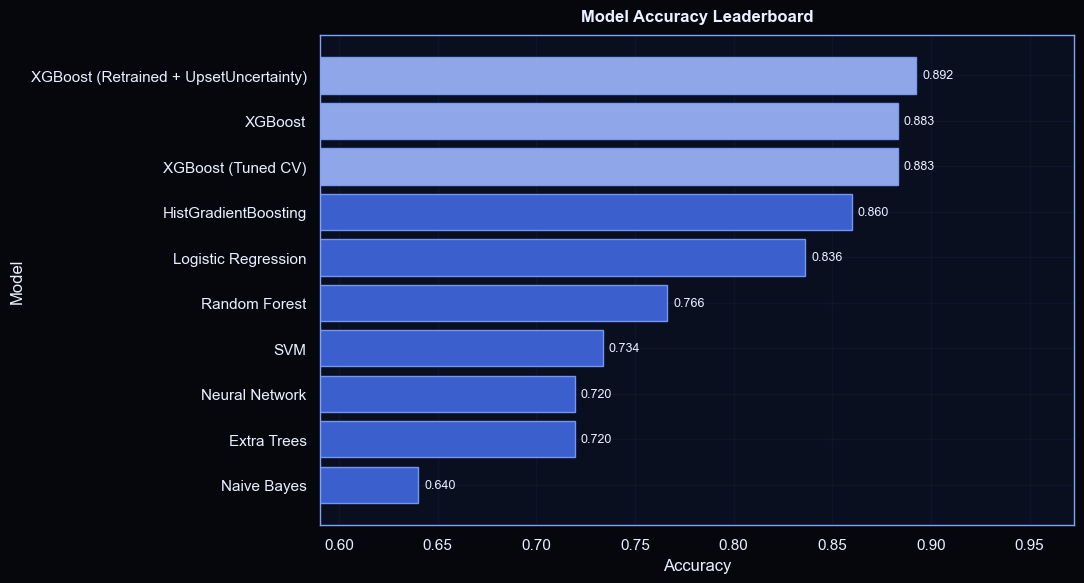

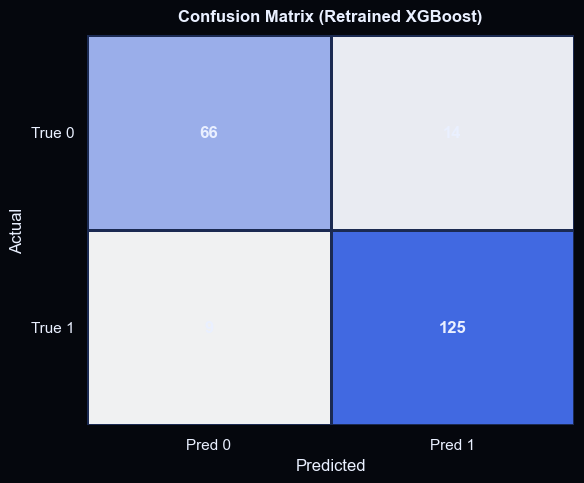

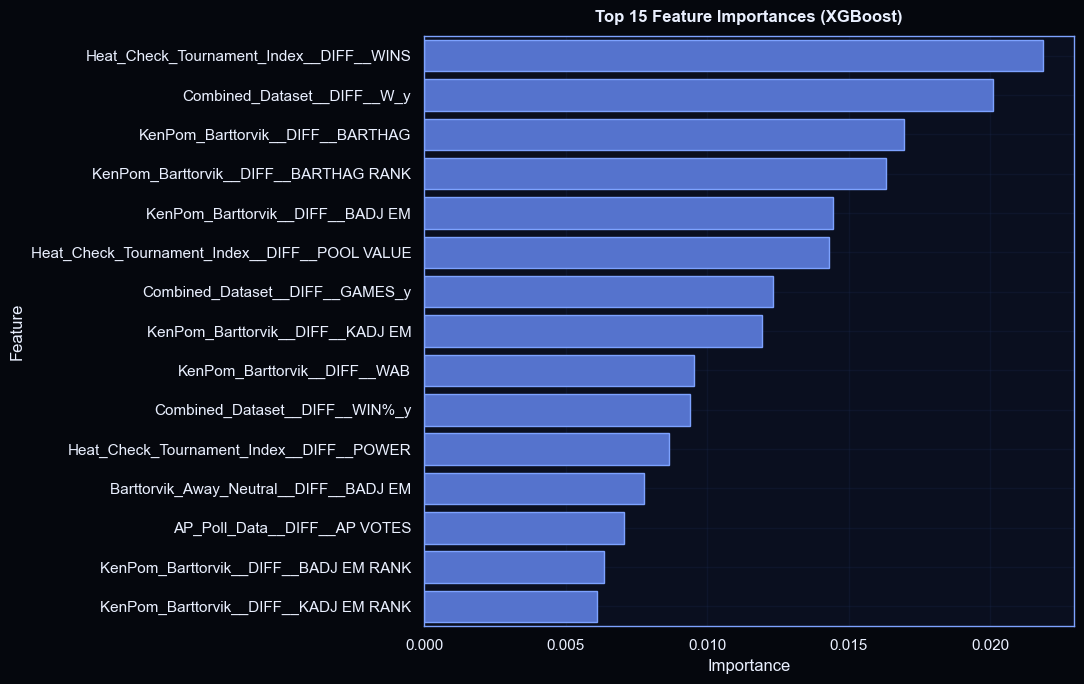

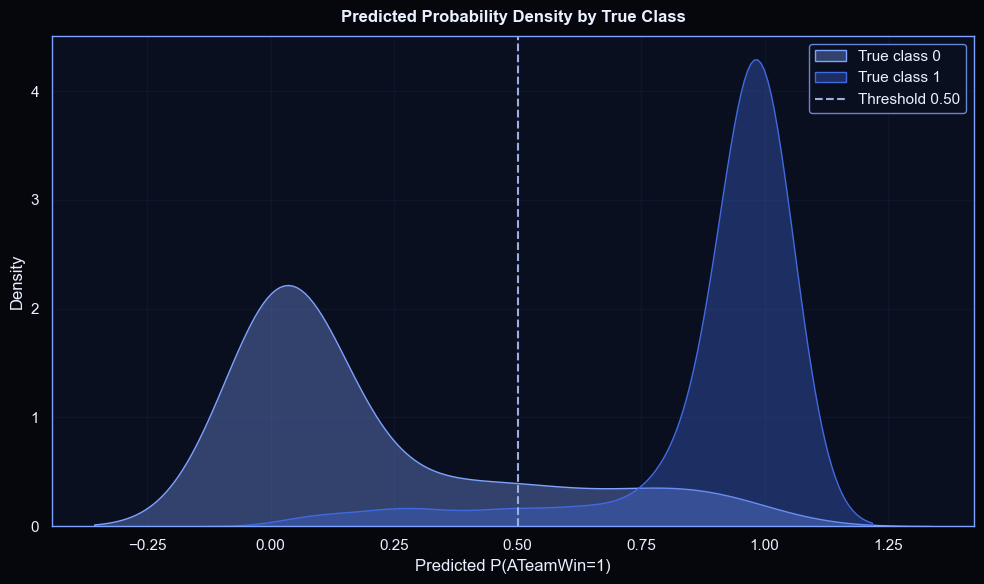

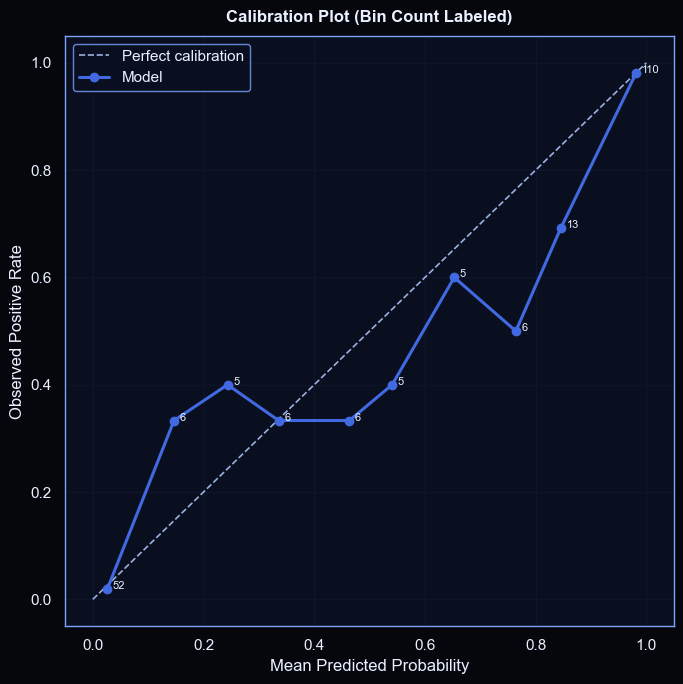

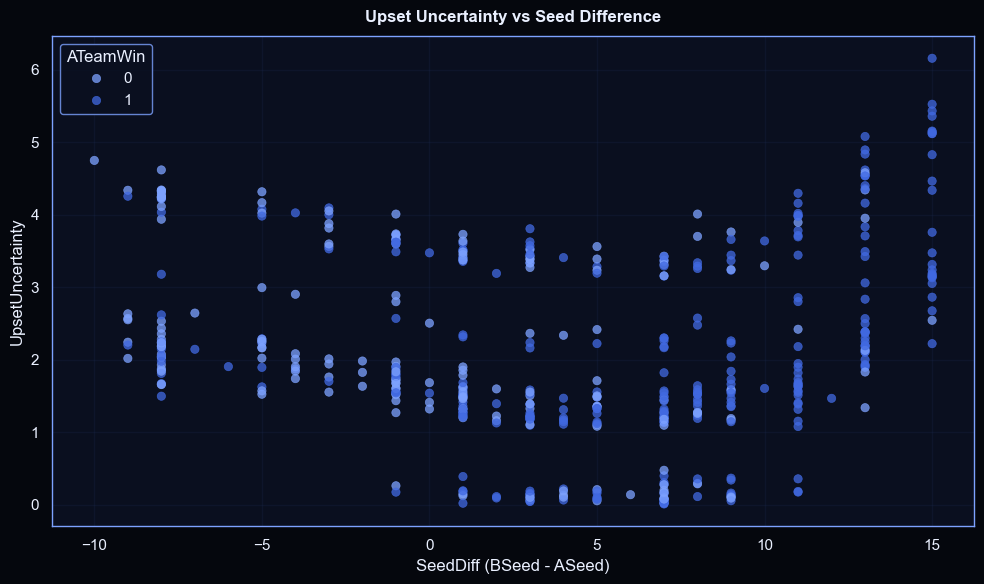

Visualization suite rendered in black + royal blue theme.


In [13]:
# Visualization dashboard: black + royal blue theme
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# Theme setup (black + royal blue)
# ----------------------------
BG = '#05070D'
PANEL = '#0A0F1F'
ROYAL = '#4169E1'
ROYAL_LIGHT = '#7DA2FF'
ROYAL_SOFT = '#9FB8FF'
GRID = '#1B2A52'
TXT = '#EAF0FF'
MUTED = '#9BB0E0'

sns.set_theme(style='darkgrid')
plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor': PANEL,
    'savefig.facecolor': BG,
    'axes.edgecolor': ROYAL_LIGHT,
    'axes.labelcolor': TXT,
    'xtick.color': TXT,
    'ytick.color': TXT,
    'text.color': TXT,
    'grid.color': GRID,
    'grid.alpha': 0.30,
    'axes.titleweight': 'bold',
})

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    for spine in ax.spines.values():
        spine.set_color(ROYAL_LIGHT)
        spine.set_linewidth(1)
    ax.tick_params(colors=TXT)
    ax.grid(True, alpha=0.25)
    if title:
        ax.set_title(title, color=TXT, fontsize=12, pad=10)
    if xlabel:
        ax.set_xlabel(xlabel, color=TXT)
    if ylabel:
        ax.set_ylabel(ylabel, color=TXT)

# Pull the latest available results table
results_tbl = None
for name in ['retrained_results', 'tuned_results', 'results_with_xgb', 'results_crazy']:
    if name in globals():
        results_tbl = globals()[name].copy()
        break

if results_tbl is None:
    raise ValueError('No model results table found. Run the model training/eval cells first.')

# ----------------------------
# 1) Model performance leaderboard
# ----------------------------
perf = results_tbl[['Model', 'Accuracy', 'Log Loss']].copy()
perf = perf.sort_values('Accuracy', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
colors = [ROYAL_SOFT if 'XGBoost' in m else ROYAL for m in perf['Model']]
ax.barh(perf['Model'], perf['Accuracy'], color=colors, edgecolor=ROYAL_LIGHT, alpha=0.9)

for i, v in enumerate(perf['Accuracy']):
    ax.text(v + 0.003, i, f'{v:.3f}', va='center', color=TXT, fontsize=9)

ax.set_xlim(max(0.5, perf['Accuracy'].min() - 0.05), min(1.0, perf['Accuracy'].max() + 0.08))
style_ax(ax, 'Model Accuracy Leaderboard', 'Accuracy', 'Model')
plt.tight_layout()
plt.show()

# ----------------------------
# 2) Confusion matrix heatmap (best available model)
# ----------------------------
cm = None
if 'retrained_cm' in globals():
    cm = np.array(retrained_cm)
elif {'y_test_retrain', 'y_pred_retrained'}.issubset(globals()):
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_test_retrain, y_pred_retrained)

if cm is not None:
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=sns.light_palette(ROYAL, as_cmap=True),
        cbar=False,
        linewidths=1,
        linecolor=GRID,
        ax=ax,
        annot_kws={'color': TXT, 'fontsize': 12, 'fontweight': 'bold'}
    )
    ax.set_xticklabels(['Pred 0', 'Pred 1'])
    ax.set_yticklabels(['True 0', 'True 1'], rotation=0)
    style_ax(ax, 'Confusion Matrix (Retrained XGBoost)', 'Predicted', 'Actual')
    plt.tight_layout()
    plt.show()

# ----------------------------
# 3) Top feature importances (XGBoost)
# ----------------------------
xgb_obj = None
for name in ['xgb_retrained', 'best_xgb_tuned', 'xgb_model', 'final_model']:
    if name in globals():
        xgb_obj = globals()[name]
        break

feature_frame = None
for name in ['X_retrain', 'X_train', 'X_full']:
    if name in globals() and isinstance(globals()[name], pd.DataFrame):
        feature_frame = globals()[name]
        break

if xgb_obj is not None and feature_frame is not None and hasattr(xgb_obj, 'feature_importances_'):
    fi = pd.DataFrame({
        'Feature': feature_frame.columns,
        'Importance': xgb_obj.feature_importances_
    }).sort_values('Importance', ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(11, 7))
    sns.barplot(data=fi, x='Importance', y='Feature', color=ROYAL, edgecolor=ROYAL_LIGHT, ax=ax)
    style_ax(ax, 'Top 15 Feature Importances (XGBoost)', 'Importance', 'Feature')
    plt.tight_layout()
    plt.show()

# ----------------------------
# 4) Probability distribution by true class
# ----------------------------
have_probs = {'y_test_retrain', 'y_proba_retrained'}.issubset(globals())
if have_probs:
    y_true = np.asarray(y_test_retrain)
    proba = np.asarray(y_proba_retrained)
    if proba.ndim == 2:
        proba = proba[:, 1]

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.kdeplot(proba[y_true == 0], fill=True, alpha=0.35, color=ROYAL_LIGHT, label='True class 0', ax=ax)
    sns.kdeplot(proba[y_true == 1], fill=True, alpha=0.35, color=ROYAL, label='True class 1', ax=ax)
    ax.axvline(0.5, color=MUTED, linestyle='--', linewidth=1.5, label='Threshold 0.50')
    style_ax(ax, 'Predicted Probability Density by True Class', 'Predicted P(ATeamWin=1)', 'Density')
    leg = ax.legend(facecolor=PANEL, edgecolor=ROYAL_LIGHT)
    for t in leg.get_texts():
        t.set_color(TXT)
    plt.tight_layout()
    plt.show()

# ----------------------------
# 5) Calibration-style curve (bin accuracy vs confidence)
# ----------------------------
if have_probs:
    y_true = np.asarray(y_test_retrain)
    proba = np.asarray(y_proba_retrained)
    if proba.ndim == 2:
        proba = proba[:, 1]

    bins = np.linspace(0, 1, 11)
    bin_ids = np.digitize(proba, bins) - 1

    rows = []
    for b in range(10):
        m = bin_ids == b
        if m.sum() == 0:
            continue
        rows.append({
            'mean_pred': proba[m].mean(),
            'frac_pos': y_true[m].mean(),
            'count': int(m.sum())
        })
    cal = pd.DataFrame(rows)

    if not cal.empty:
        fig, ax = plt.subplots(figsize=(7, 7))
        ax.plot([0, 1], [0, 1], linestyle='--', color=MUTED, linewidth=1.2, label='Perfect calibration')
        ax.plot(cal['mean_pred'], cal['frac_pos'], marker='o', color=ROYAL, linewidth=2.2, label='Model')

        for _, r in cal.iterrows():
            ax.text(r['mean_pred'] + 0.01, r['frac_pos'], str(int(r['count'])), color=TXT, fontsize=8)

        style_ax(ax, 'Calibration Plot (Bin Count Labeled)', 'Mean Predicted Probability', 'Observed Positive Rate')
        leg = ax.legend(facecolor=PANEL, edgecolor=ROYAL_LIGHT)
        for t in leg.get_texts():
            t.set_color(TXT)
        plt.tight_layout()
        plt.show()

# ----------------------------
# 6) Upset uncertainty vs seed gap
# ----------------------------
if {'UpsetUncertainty', 'SeedDiff', 'ATeamWin'}.issubset(enriched_games.columns):
    viz_df = enriched_games[['UpsetUncertainty', 'SeedDiff', 'ATeamWin']].dropna().copy()

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.scatterplot(
        data=viz_df.sample(min(len(viz_df), 500), random_state=42),
        x='SeedDiff',
        y='UpsetUncertainty',
        hue='ATeamWin',
        palette={0: ROYAL_LIGHT, 1: ROYAL},
        alpha=0.75,
        edgecolor=None,
        ax=ax,
    )
    style_ax(ax, 'Upset Uncertainty vs Seed Difference', 'SeedDiff (BSeed - ASeed)', 'UpsetUncertainty')
    leg = ax.legend(title='ATeamWin', facecolor=PANEL, edgecolor=ROYAL_LIGHT)
    for t in leg.get_texts():
        t.set_color(TXT)
    if leg.get_title() is not None:
        leg.get_title().set_color(TXT)
    plt.tight_layout()
    plt.show()

print('Visualization suite rendered in black + royal blue theme.')

In [15]:
%pip install plotly

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 9.9 MB 4.1 MB/s eta 0:00:01
     |████████████████████████████████| 444 kB 6.6 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [28]:
# Interactive Plotly dashboard export (black + royal blue) for website embedding
import os
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# ----------------------------
# Theme setup (black + royal blue)
# ----------------------------
BG = '#05070D'
PANEL = '#0A0F1F'
ROYAL = '#4169E1'
ROYAL_LIGHT = '#7DA2FF'
ROYAL_SOFT = '#9FB8FF'
GRID = '#1B2A52'
TXT = '#EAF0FF'
MUTED = '#9BB0E0'

EXPORT_DIR = 'web_charts'
os.makedirs(EXPORT_DIR, exist_ok=True)


def apply_theme(fig):
    fig.update_layout(
        paper_bgcolor=BG,
        plot_bgcolor=PANEL,
        font=dict(color=TXT),
        xaxis=dict(gridcolor=GRID, zerolinecolor=GRID, linecolor=ROYAL_LIGHT),
        yaxis=dict(gridcolor=GRID, zerolinecolor=GRID, linecolor=ROYAL_LIGHT),
        legend=dict(bgcolor=PANEL, bordercolor=ROYAL_LIGHT, borderwidth=1),
        margin=dict(l=60, r=40, t=70, b=55),
    )
    return fig


def export_fig(fig, filename):
    path = os.path.join(EXPORT_DIR, filename)
    fig.write_html(path, include_plotlyjs='cdn', full_html=True)
    return path


saved_paths = []

# Pull latest available results table
results_tbl = None
for name in ['retrained_results', 'tuned_results', 'results_with_xgb', 'results_crazy']:
    if name in globals():
        results_tbl = globals()[name].copy()
        break

if results_tbl is None:
    raise ValueError('No model results table found. Run model training/eval cells first.')

# ----------------------------
# 1) Model performance leaderboard
# ----------------------------
perf = results_tbl[['Model', 'Accuracy', 'Log Loss']].copy().sort_values('Accuracy', ascending=True)
perf['Color'] = np.where(perf['Model'].str.contains('XGBoost', na=False), 'XGBoost', 'Other')

model_descriptions = {
    'Logistic Regression': 'A simple linear model that weighs features and outputs a win probability.',
    'Neural Network': 'A layered model that learns non-linear patterns by combining many weighted signals.',
    'SVM': 'Finds a boundary that best separates winners from losers in feature space.',
    'Random Forest': 'An ensemble of many decision trees that vote on the final prediction.',
    'Naive Bayes': 'A probability model that combines features under independence assumptions.',
    'Extra Trees': 'A tree ensemble like random forest, but with more random splits for diversity.',
    'HistGradientBoosting': 'Builds many small trees sequentially, each correcting earlier mistakes.',
    'XGBoost': 'A boosted tree model that iteratively improves predictions with strong regularization.',
    'XGBoost (Tuned CV)': 'XGBoost with hyperparameters tuned via cross-validation for better generalization.',
    'XGBoost (Retrained + UpsetUncertainty)': 'Tuned XGBoost retrained with uncertainty features to better capture upset risk.',
}

perf['ModelExplanation'] = perf['Model'].map(model_descriptions).fillna(
    'Predictive model that combines matchup features to estimate win probability.'
)

fig1 = px.bar(
    perf,
    x='Accuracy',
    y='Model',
    orientation='h',
    color='Color',
    color_discrete_map={'XGBoost': ROYAL_SOFT, 'Other': ROYAL},
    text=perf['Accuracy'].map(lambda v: f'{v:.3f}'),
    custom_data=['ModelExplanation'],
    title='Model Accuracy Leaderboard',
)

fig1.update_traces(
    textposition='outside',
    marker_line_color=ROYAL_LIGHT,
    marker_line_width=1,
    hovertemplate='<b>%{y}</b><br>%{customdata[0]}<extra></extra>',
)
fig1.update_layout(showlegend=False)
fig1.update_xaxes(range=[max(0.5, perf['Accuracy'].min() - 0.05), min(1.0, perf['Accuracy'].max() + 0.08)])
fig1 = apply_theme(fig1)
fig1.show()
saved_paths.append(export_fig(fig1, '01_model_accuracy_leaderboard.html'))

# ----------------------------
# 2) Confusion matrix heatmap
# ----------------------------
cm = None
if 'retrained_cm' in globals():
    cm = np.array(retrained_cm)
elif {'y_test_retrain', 'y_pred_retrained'}.issubset(globals()):
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_test_retrain, y_pred_retrained)

if cm is not None:
    fig2 = px.imshow(
        cm,
        text_auto=True,
        color_continuous_scale=[[0, PANEL], [1, ROYAL]],
        x=['Predicted 0', 'Predicted 1'],
        y=['Actual 0', 'Actual 1'],
        title='Confusion Matrix (Retrained XGBoost)',
    )

    cm_explanations = np.array([
        [
            'These are games the model correctly called as Team A losses.',
            'These are games the model said Team A would win, but Team A actually lost.',
        ],
        [
            'These are games the model said Team A would lose, but Team A actually won.',
            'These are games the model correctly called as Team A wins.',
        ],
    ], dtype=object)

    fig2.update_traces(
        customdata=cm_explanations,
        hovertemplate='Count: %{z}<br>%{customdata}<extra></extra>',
    )
    fig2.update_layout(coloraxis_showscale=False)
    fig2 = apply_theme(fig2)
    fig2.update_xaxes(side='top')
    fig2.show()
    saved_paths.append(export_fig(fig2, '02_confusion_matrix.html'))

# ----------------------------
# 3) Top feature importances
# ----------------------------
xgb_obj = None
for name in ['xgb_retrained', 'best_xgb_tuned', 'xgb_model', 'final_model']:
    if name in globals():
        xgb_obj = globals()[name]
        break

feature_frame = None
for name in ['X_retrain', 'X_train', 'X_full']:
    if name in globals() and isinstance(globals()[name], pd.DataFrame):
        feature_frame = globals()[name]
        break

if xgb_obj is not None and feature_frame is not None and hasattr(xgb_obj, 'feature_importances_'):
    fi = pd.DataFrame({'Feature': feature_frame.columns, 'Importance': xgb_obj.feature_importances_})
    fi = fi.sort_values('Importance', ascending=False).head(15).sort_values('Importance', ascending=True)

    metric_explanations = {
        'Heat_Check_Tournament_Index__DIFF__WINS': 'Difference in projected wins from Heat Check Tournament Index (Team A minus Team B). <br>Higher means Team A is projected to win more games.',
        'Combined_Dataset__DIFF__W_y': 'Difference in historical wins column from the combined dataset (A minus B). <br>Positive values favor Team A based on win volume.',
        'KenPom_Barttorvik__DIFF__BARTHAG': 'Difference in BARTHAG (win-quality/efficiency-based strength metric). <br>Positive means Team A has stronger overall profile.',
        'KenPom_Barttorvik__DIFF__BARTHAG RANK': 'Difference in BARTHAG rank between teams (A minus B). <br>Lower/better rank for Team A typically improves win odds.',
        'KenPom_Barttorvik__DIFF__BADJ EM': 'Difference in Barttorvik adjusted efficiency margin (offense minus defense quality). <br>Positive means Team A is stronger per-possession.',
        'Heat_Check_Tournament_Index__DIFF__POOL VALUE': 'Difference in Heat Check pool value (upside/value in bracket pools). <br>Positive means Team A provides more modeled pool value.',
        'Combined_Dataset__DIFF__GAMES_y': 'Difference in total games played from the combined dataset (A minus B). <br>Captures experience/workload profile differences.',
        'KenPom_Barttorvik__DIFF__KADJ EM': 'Difference in KenPom adjusted efficiency margin. <br>Positive means Team A has better expected scoring margin per 100 possessions.',
        'KenPom_Barttorvik__DIFF__WAB': 'Difference in Wins Above Bubble (resume strength above bubble baseline). <br>Positive means Team A has the stronger resume.',
        'Combined_Dataset__DIFF__WIN%_y': 'Difference in win percentage from the combined dataset (A minus B). <br>Positive means Team A has won at a higher rate.',
        'Heat_Check_Tournament_Index__DIFF__POWER': 'Difference in Heat Check power rating (overall team power). <br>Positive means Team A rates stronger.',
        'Barttorvik_Away_Neutral__DIFF__BADJ EM': 'Difference in Barttorvik adjusted efficiency margin on away/neutral context. <br>Positive means Team A travels/neutralizes better.',
        'AP_Poll_Data__DIFF__AP VOTES': 'Difference in AP poll votes (A minus B). <br>Positive means Team A receives more poll support/public respect.',
        'KenPom_Barttorvik__DIFF__BADJ EM RANK': 'Difference in Barttorvik adjusted efficiency rank. <br>Better relative rank for Team A generally increases expected win probability.',
        'KenPom_Barttorvik__DIFF__KADJ EM RANK': 'Difference in KenPom adjusted efficiency rank. <br>Better relative rank for Team A generally increases expected win probability.',
    }

    def describe_metric(feature_name):
        feature_name = str(feature_name)
        if feature_name in metric_explanations:
            return metric_explanations[feature_name]

        f = feature_name.upper()
        if '__DIFF__' in f or 'DIFF' in f:
            return 'Team A minus Team B for this metric. Positive means Team A rates higher; negative means Team B does.'
        return 'Engineered matchup feature used by XGBoost to estimate Team A win probability.'

    fi['MetricExplanation'] = fi['Feature'].apply(describe_metric)

    fig3 = px.bar(
        fi,
        x='Importance',
        y='Feature',
        orientation='h',
        title='Top 15 Feature Importances (XGBoost)',
        color_discrete_sequence=[ROYAL],
    )
    fig3.update_traces(
        marker_line_color=ROYAL_LIGHT,
        marker_line_width=1,
        customdata=np.stack([fi['MetricExplanation']], axis=-1),
        hovertemplate='<b>%{y}</b><br>%{customdata[0]}<br>Importance: %{x:.4f}<extra></extra>',
    )
    fig3 = apply_theme(fig3)
    fig3.show()
    saved_paths.append(export_fig(fig3, '03_top_feature_importances.html'))

# ----------------------------
# 4) Predicted probability distribution by true class
# ----------------------------
have_probs = {'y_test_retrain', 'y_proba_retrained'}.issubset(globals())
if have_probs:
    y_true = np.asarray(y_test_retrain)
    proba = np.asarray(y_proba_retrained)
    if proba.ndim == 2:
        proba = proba[:, 1]

    dist_df = pd.DataFrame({
        'PredictedProb': proba,
        'TrueClass': np.where(y_true == 1, 'True class 1', 'True class 0')
    })

    fig4 = px.histogram(
        dist_df,
        x='PredictedProb',
        color='TrueClass',
        nbins=30,
        barmode='overlay',
        opacity=0.55,
        color_discrete_map={'True class 0': ROYAL_LIGHT, 'True class 1': ROYAL},
        title='Predicted Probability Distribution by True Class',
    )
    fig4.add_vline(x=0.5, line_dash='dash', line_color=MUTED, annotation_text='Threshold 0.50', annotation_font_color=TXT)
    fig4 = apply_theme(fig4)
    fig4.show()
    saved_paths.append(export_fig(fig4, '04_probability_distribution.html'))

# ----------------------------
# 5) Calibration-style curve
# ----------------------------
if have_probs:
    y_true = np.asarray(y_test_retrain)
    proba = np.asarray(y_proba_retrained)
    if proba.ndim == 2:
        proba = proba[:, 1]

    bins = np.linspace(0, 1, 11)
    bin_ids = np.digitize(proba, bins) - 1

    rows = []
    for b in range(10):
        m = bin_ids == b
        if m.sum() == 0:
            continue
        rows.append({'mean_pred': float(proba[m].mean()), 'frac_pos': float(y_true[m].mean()), 'count': int(m.sum())})
    cal = pd.DataFrame(rows)

    if not cal.empty:
        fig5 = go.Figure()
        fig5.add_trace(go.Scatter(
            x=[0, 1],
            y=[0, 1],
            mode='lines',
            name='Perfect calibration',
            line=dict(color=MUTED, dash='dash')
        ))
        fig5.add_trace(go.Scatter(
            x=cal['mean_pred'],
            y=cal['frac_pos'],
            mode='lines+markers+text',
            text=cal['count'].astype(str),
            textposition='top center',
            name='Model',
            line=dict(color=ROYAL, width=3),
            marker=dict(color=ROYAL_LIGHT, size=9)
        ))
        fig5.update_layout(title='Calibration Plot (Labels = Bin Counts)', xaxis_title='Mean Predicted Probability', yaxis_title='Observed Positive Rate')
        fig5 = apply_theme(fig5)
        fig5.show()
        saved_paths.append(export_fig(fig5, '05_calibration_curve.html'))

# ----------------------------
# 6) Upset uncertainty vs seed difference
# ----------------------------
if {'UpsetUncertainty', 'SeedDiff', 'ATeamWin'}.issubset(enriched_games.columns):
    viz_df = enriched_games[['UpsetUncertainty', 'SeedDiff', 'ATeamWin']].dropna().copy()
    if len(viz_df) > 500:
        viz_df = viz_df.sample(500, random_state=42)

    viz_df['ATeamWinLabel'] = viz_df['ATeamWin'].map({0: 'Loss (0)', 1: 'Win (1)'})
    fig6 = px.scatter(
        viz_df,
        x='SeedDiff',
        y='UpsetUncertainty',
        color='ATeamWinLabel',
        color_discrete_map={'Loss (0)': ROYAL_LIGHT, 'Win (1)': ROYAL},
        opacity=0.75,
        title='Upset Uncertainty vs Seed Difference',
        hover_data=['ATeamWin']
    )
    fig6.update_layout(xaxis_title='SeedDiff (BSeed - ASeed)', yaxis_title='UpsetUncertainty')
    fig6 = apply_theme(fig6)
    fig6.show()
    saved_paths.append(export_fig(fig6, '06_upset_uncertainty_scatter.html'))

# Optional index page for easy embedding/testing
index_html = os.path.join(EXPORT_DIR, 'index.html')
with open(index_html, 'w', encoding='utf-8') as f:
    f.write('<!doctype html><html><head><meta charset="utf-8"><title>Web Charts</title></head><body style="background:#05070D;color:#EAF0FF;font-family:Arial,sans-serif;">')
    f.write('<h2>Interactive Charts</h2>')
    for p in saved_paths:
        name = os.path.basename(p)
        f.write(f'<div style="margin:16px 0;"><a href="{name}" style="color:#7DA2FF">{name}</a></div>')
    f.write('</body></html>')

print('Saved interactive charts to:', EXPORT_DIR)
for p in saved_paths:
    print('-', p)
print('-', index_html)
print('Use these .html files directly in iframes or web templates.')

Saved interactive charts to: web_charts
- web_charts/01_model_accuracy_leaderboard.html
- web_charts/02_confusion_matrix.html
- web_charts/03_top_feature_importances.html
- web_charts/04_probability_distribution.html
- web_charts/05_calibration_curve.html
- web_charts/06_upset_uncertainty_scatter.html
- web_charts/index.html
Use these .html files directly in iframes or web templates.
